In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [4]:
# Evaluation -- Random Forest

df = pd.read_csv('../../data/joined/augmented_properties_with_distances.csv',  low_memory=False)
df['log_fullval'] = np.log(df['FULLVAL'] + 1)

# New features
df['log_dist_bus'] = np.log(df['dist_to_bus_m'] + 1)  # + 1 avoids log(0)
df['log_dist_subway'] = np.log(df['dist_to_subway_m'] + 1)
df['num_subway_routes'] = df['nearest_subway_routes'].str.split(',').str.len().fillna(0)  # Count routes

In [ ]:
def process_data(df, debug=False):
    # Select expanded X - drop any NaNs after deriving
    X = df[['log_dist_bus', 'log_dist_subway', 'TAXCLASS', 'num_subway_routes', 'NTA']].copy()
    y = df['log_fullval']

    # Handle categories: One hot NTA (top 20 for simplicity --- full would use all)
    top_ntas = X['NTA'].value_counts().head(20).index
    X['NTA'] = X['NTA'].apply(lambda x: x if x in top_ntas else 'Other')

    # Drop NaNs
    mask = ~(X.isna().any(axis=1)) & y.notna()
    X_clean = X[mask]
    y_clean = y[mask]
    if debug:
        print(f"Shape after dropping NaNs: {X_clean.shape} (dropped {len(X) - len(X_clean)} rows)")

    # Pipeline for preprocessing 
    preprocessor = ColumnTransformer(transformers=[('cat', OneHotEncoder(drop='first', sparse_output=False), ['NTA'])], remainder='passthrough')

    # Split and fit pipeline with Random Forest
    X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2)
    
    # Ensure Test data only includes data from training
    test_NTAs = X_test['NTA'].copy()
    X_test = X_test[test_NTAs.isin(X_train['NTA'].unique())]
    y_test = y_test[test_NTAs.isin(X_train['NTA'].unique())]

    model = Pipeline([('preproc', preprocessor),('rf', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))])
    model.fit(X_train, y_train)

    # Predict and score
    y_pred = model.predict(X_test)
    if debug:
        print(f"R-squared score on test set: {r2_score(y_test, y_pred):.4f}")

    # Feature importances - see if we can extract any insights
    importances = model.named_steps['rf'].feature_importances_
    feature_names = ([
        ('NTA_' + name for name in top_ntas[1:]),  # Skip first for drop
        'log_dist_bus', 
        'log_dist_subway', 
        'TAXCLASS', 
        'num_subway_routes'
    ])
    top_feature_imps = {feature_names[i]: importances[i] for i in range(len(feature_names))}
    if debug:
        print("Top feature importances:", top_feature_imps)

    return r2_score(y_test, y_pred), top_feature_imps

In [163]:
def zone_models(df, separator, num_seps=4, headnum=20, debug=False):
    # Run model on dataset separated by zone
    res = []

    # Find number of separations to test with
    sep_vals = [x for x in np.linspace(start=0, stop=1.0, num=num_seps+1)]
    if debug:
        print(f"{sep_vals=}")

    for zone in df[separator].value_counts().head(headnum).index:
        # Isolate zones in df
        df_z = df[df[separator] == zone]
        if debug:
            print(f"Length of {zone}={len(df_z)}")
            print(df_z.columns)
        
        if len(df_z) < 20:
            continue

        r2_list = []
        tfi_list = []

        # For all income ranges, get r2 and tfi
        for i in range(len(sep_vals) - 1):
            
            # Find custom bounds
            start = sep_vals[i]
            start_q = df_z['log_fullval'].quantile(start) if start > 0 else min(df_z['log_fullval'])
            end = sep_vals[i+1]
            end_q = df_z['log_fullval'].quantile(end)
            
            if debug:
                print(f"{start=} {start_q=} {end=} {end_q=}")

            # Process bounded data
            r2_ret, tfi_ret = process_data(df_z[df_z['log_fullval'].between(start_q, end_q)], debug=debug)
            r2_list.append(r2_ret)
            tfi_list.append(tfi_ret)

        res.append((zone, r2_list, tfi_list))

    return res

In [125]:
def save_zone_results(res, territory_type, num_seps=4, debug=False):
    df = pd.DataFrame(columns=['DISTRICT_NAME', 'TERRITORY_TYPE', 'VALUATION_SEPARATION', 'r2_score', 'log_dist_subway', 'log_dist_bus', 'TAXCLASS', 'num_subway_routes'])
    for dist_name, r2, feat_imps in res:
        if debug:
            print(f"{dist_name=} {r2=} {feat_imps=}")
        for i in range(num_seps):
            df.loc[len(df)] = [
                dist_name,
                territory_type,
                i,
                r2[i],
                feat_imps[i]['log_dist_subway'],
                feat_imps[i]['log_dist_bus'],
                feat_imps[i]['TAXCLASS'],
                feat_imps[i]['num_subway_routes']
            ]
    df.to_csv(f"../../data/results/{territory_type}_results_{num_seps}.csv", index=False)

    return df

## Zone Results

In [115]:
res_nta = zone_models(df, "NTA", headnum=50, num_seps=10, debug=False)

In [116]:
df_nta = save_zone_results(res=res_nta, territory_type="NTA", num_seps=10, debug=False)

## Borough Results

In [164]:
res_bor = zone_models(df, "Borough", num_seps=10, debug=False)

IndexError: list index out of range

In [ ]:
df_bor = save_zone_results(res=res_bor, territory_type="BOR", num_seps=10, debug=False)

In [154]:
pd.Series(["Brownsville", "Upper West Side"]).isin(df_nta["DISTRICT_NAME"].unique())

0    True
1    True
dtype: bool

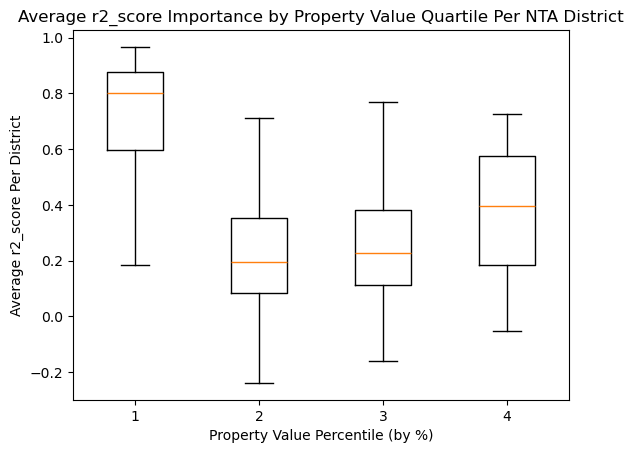

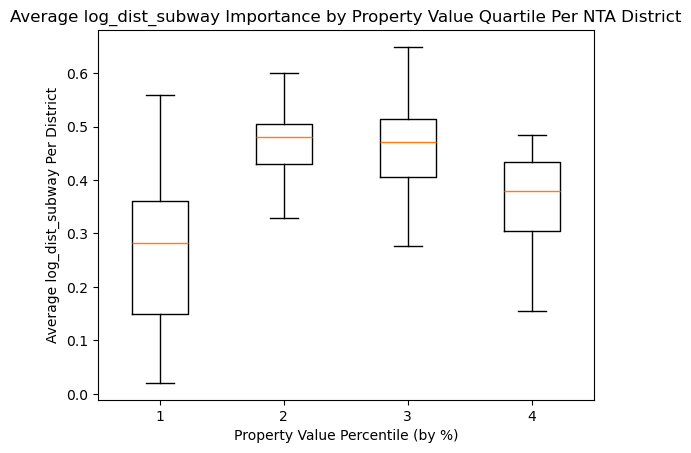

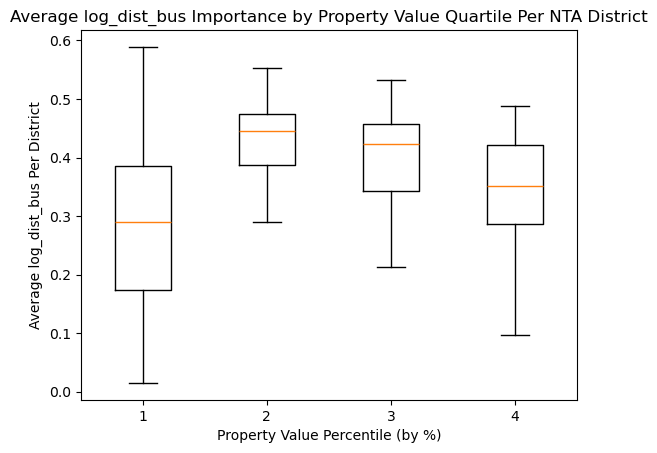

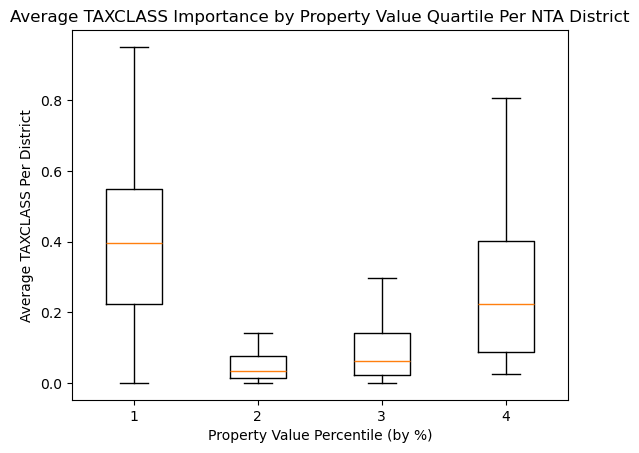

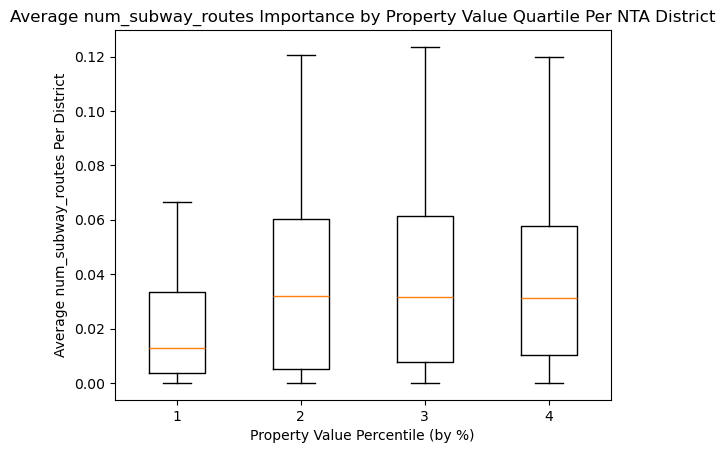

In [ ]:
for met in ['r2_score', 'log_dist_subway', 'log_dist_bus', 'TAXCLASS', 'num_subway_routes']:
    data = []
    for i in range(10):
        data.append(df_nta[df_nta["VALUATION_SEPARATION"] == i][met])
    plt.boxplot(data, label=[x for x in range(10, 101, 10)], showfliers=False)
    plt.title(f"Average {met} Importance by Property Value Quartile Per NTA District")
    plt.xlabel("Property Value Percentile (by %)")
    plt.ylabel(f"Average {met} Per District")

    plt.savefig(f"../../figures/NTA_feature_importance_10_seps/NTA_{met}.jpg")

    plt.show()

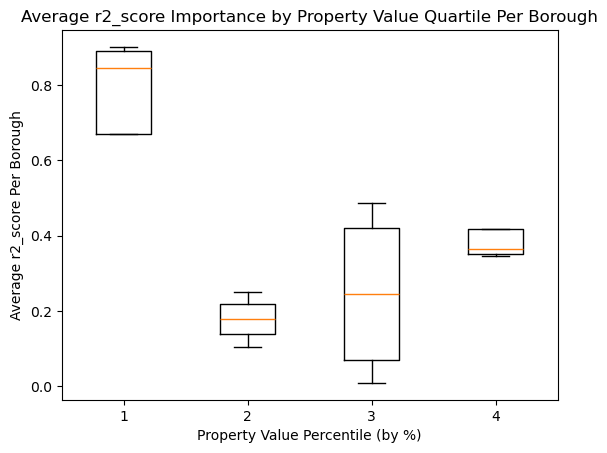

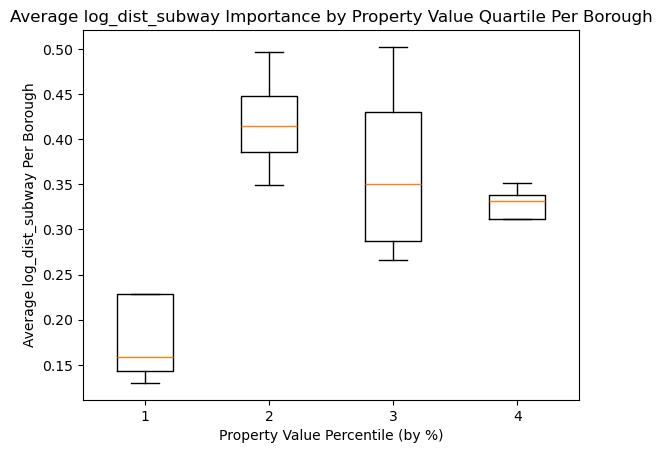

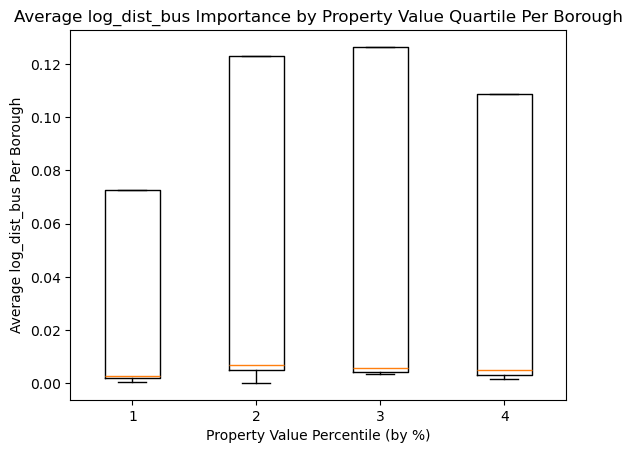

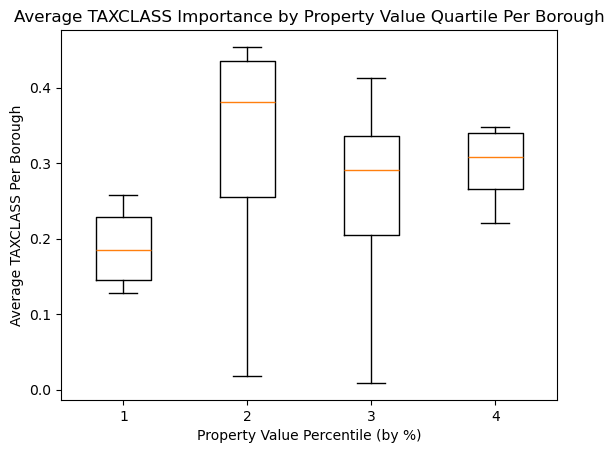

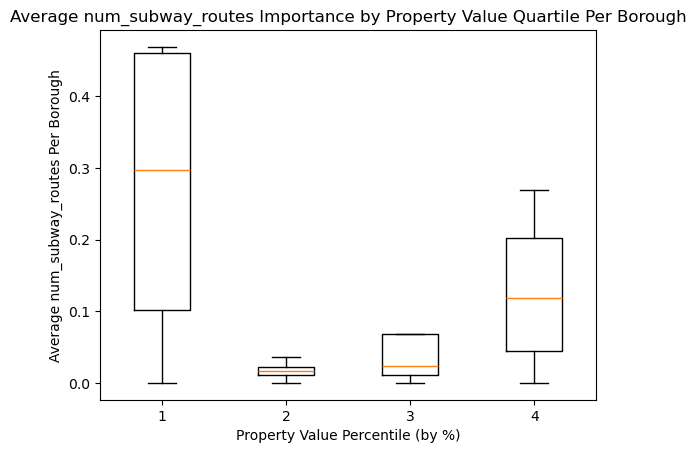

In [ ]:
for met in ['r2_score', 'log_dist_subway', 'log_dist_bus', 'TAXCLASS', 'num_subway_routes']:
    data = []
    for i in range(10):
        data.append(df_bor[df_bor["VALUATION_SEPARATION"] == i][met])
    plt.boxplot(data, label=[x for x in range(10, 101, 10)], showfliers=False)
    plt.title(f"Average {met} Importance by Property Value Quartile Per Borough")
    plt.xlabel("Property Value Percentile (by %)")
    plt.ylabel(f"Average {met} Per Borough")

    plt.savefig(f"../../figures/BOR_feature_importance_10_seps/BOR_{met}.jpg")

    plt.show()